<a href="https://colab.research.google.com/github/GusevaAnna/Projects/blob/main/%D0%A2%D0%B5%D1%81%D1%82%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%D0%A1%D0%9C%D0%9F%D0%A0%D0%9E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== ЗАГРУЗКА И ОБРАБОТКА ДАННЫХ ====================

print("📥 ЗАГРУЗКА ФАЙЛА...")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
raw_df = pd.read_excel(file_name, sheet_name='Лист1', header=None)

print("🔄 ОБРАБОТКА ДАННЫХ...")

# Функция для обработки данных
def process_construction_data(df):
    result_data = []

    current_material = None
    current_material_code = None
    current_unit = None
    current_unit_code = None

    for i in range(len(df)):
        row = df.iloc[i]

        # Пропускаем пустые строки
        if pd.isna(row[0]) and pd.isna(row[1]):
            continue

        # Строка с материалом
        if (pd.notna(row[0]) and pd.notna(row[1]) and
            isinstance(row[1], str) and any(char.isdigit() and '.' in row[1] for char in row[1])):
            current_material = row[0]
            current_material_code = row[1]
            current_unit = None
            current_unit_code = None

        # Строка с единицей измерения
        elif (pd.notna(row[0]) and pd.notna(row[1]) and
              current_material is not None and current_unit is None and
              not (isinstance(row[1], str) and '.' in row[1])):
            current_unit = row[0]
            current_unit_code = row[1]

        # Строка с данными региона
        elif (pd.notna(row[0]) and pd.notna(row[1]) and
              current_material is not None and current_unit is not None and
              str(row[1]).strip() not in ['', 'А', 'Б', '1', '2', '3', '4', '5', '6', '7', '8'] and
              len(str(row[1])) >= 2):

            def safe_convert(value):
                try:
                    if pd.isna(value) or value == '':
                        return np.nan
                    if isinstance(value, str):
                        return float(value.replace(',', '.'))
                    return float(value)
                except (ValueError, TypeError):
                    return np.nan

            region_data = {
                'Материал': current_material,
                'Код_материала': current_material_code,
                'Единица_измерения': current_unit,
                'Код_единицы': current_unit_code,
                'Регион': row[0],
                'Код_региона': row[1],
                'Отчетный_месяц': safe_convert(row[2]),
                'Предыдущий_месяц': safe_convert(row[3]),
                'Месяц_прошлого_года': safe_convert(row[4]),
                'Период_с_начала_года': safe_convert(row[5]),
                'Период_прошлого_года': safe_convert(row[6]),
                'Темп_роста_к_пред_месяцу': safe_convert(row[7]),
                'Темп_роста_к_месяцу_прошлого_года': safe_convert(row[8]),
                'Темп_роста_к_периоду_прошлого_года': safe_convert(row[9])
            }
            result_data.append(region_data)

    return pd.DataFrame(result_data)

# Обрабатываем данные
df = process_construction_data(raw_df)

# Заполняем пропуски в категориальных столбцах
df['Материал'] = df['Материал'].fillna(method='ffill')
df['Код_материала'] = df['Код_материала'].fillna(method='ffill')
df['Единица_измерения'] = df['Единица_измерения'].fillna(method='ffill')
df['Код_единицы'] = df['Код_единицы'].fillna(method='ffill')

# Очищаем от строк с пустыми регионами
df = df.dropna(subset=['Регион'])

# Функция для определения типа региона
def identify_region_type(region_name):
    region_str = str(region_name).lower()
    if 'российская федерация' in region_str:
        return 'Страна'
    elif 'федеральный округ' in region_str:
        return 'Федеральный округ'
    elif any(keyword in region_str for keyword in ['область', 'край', 'республика', 'автономный']):
        return 'Субъект РФ'
    elif any(keyword in region_str for keyword in ['город', 'г. ']):
        return 'Город'
    else:
        return 'Другое'

# Добавляем столбец с типом региона
df['Тип_региона'] = df['Регион'].apply(identify_region_type)

print("✅ ДАННЫЕ УСПЕШНО ОБРАБОТАНЫ")

📥 ЗАГРУЗКА ФАЙЛА...


Saving Тестовое задание.xlsx to Тестовое задание (6).xlsx
🔄 ОБРАБОТКА ДАННЫХ...
✅ ДАННЫЕ УСПЕШНО ОБРАБОТАНЫ


/tmp/ipython-input-1233555361.py:87: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Материал'] = df['Материал'].fillna(method='ffill')
/tmp/ipython-input-1233555361.py:88: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Код_материала'] = df['Код_материала'].fillna(method='ffill')
/tmp/ipython-input-1233555361.py:89: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Единица_измерения'] = df['Единица_измерения'].fillna(method='ffill')
/tmp/ipython-input-1233555361.py:90: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Код_единицы'] = df['Код_единицы'].fillna(method='ffill')


In [2]:
# ==================== АНАЛИЗ ДАННЫХ ====================

print("\n" + "="*60)
print("📊 КОМПЛЕКСНЫЙ АНАЛИЗ ДАННЫХ")
print("="*60)

print("\n📈 ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ:")
print(f"• Размер данных: {df.shape[0]:,} строк, {df.shape[1]} столбцов".replace(',', ' '))
print(f"• Объем памяти: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

print(f"\n🏷️ СТРУКТУРА ДАННЫХ:")
print(f"• Уникальных материалов: {df['Материал'].nunique()}")
print(f"• Уникальных регионов: {df['Регион'].nunique()}")
print(f"• Распределение по типам регионов:")
for region_type, count in df['Тип_региона'].value_counts().items():
    print(f"  - {region_type}: {count} записей")

# Анализ пропущенных значений
print("\n🔍 АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100)
missing_info = pd.DataFrame({
    'Пропущено': missing_data,
    'Процент': missing_percent
})
missing_data_exists = missing_info[missing_info['Пропущено'] > 0]
if len(missing_data_exists) > 0:
    print(missing_data_exists)
else:
    print("✅ Пропущенных значений нет")

# Топ материалы по частоте встречаемости
print("\n🏭 ТОП-10 САМЫХ РАСПРОСТРАНЕННЫХ МАТЕРИАЛОВ:")
top_materials_count = df['Материал'].value_counts().head(10)
for i, (material, count) in enumerate(top_materials_count.items(), 1):
    short_name = material[:70] + "..." if len(material) > 70 else material
    print(f"{i:2d}. {short_name}: {count} записей")

# Топ материалы по объему производства
print("\n💰 ТОП-5 МАТЕРИАЛОВ ПО ОБЪЕМУ ПРОИЗВОДСТВА:")
top_materials_volume = df.groupby('Материал')['Отчетный_месяц'].sum().sort_values(ascending=False).head(5)
for i, (material, volume) in enumerate(top_materials_volume.items(), 1):
    short_name = material[:60] + "..." if len(material) > 60 else material
    print(f"{i}. {short_name}: {volume:,.0f} ед.".replace(',', ' '))

# Анализ по федеральным округам
print("\n🌐 ОБЪЕМЫ ПРОИЗВОДСТВА ПО ФЕДЕРАЛЬНЫМ ОКРУГАМ:")
federal_data = df[df['Тип_региона'] == 'Федеральный округ'].groupby('Регион')['Отчетный_месяц'].sum().sort_values(ascending=False)
for region, volume in federal_data.items():
    print(f"• {region}: {volume:,.0f} ед.".replace(',', ' '))

# Статистика по числовым столбцам
print("\n📊 СТАТИСТИКА ПО ЧИСЛОВЫМ ПОКАЗАТЕЛЯМ:")
numeric_columns = ['Отчетный_месяц', 'Предыдущий_месяц', 'Месяц_прошлого_года',
                  'Период_с_начала_года', 'Период_прошлого_года']
stats = df[numeric_columns].describe()
print(stats.round(2))

# ==================== АНАЛИТИЧЕСКИЕ ЗАПРОСЫ ====================

print("\n" + "="*60)
print("🔍 КЛЮЧЕВЫЕ АНАЛИТИЧЕСКИЕ ВЫВОДЫ")
print("="*60)

# 1. Материалы с наибольшим ростом
print("\n🚀 МАТЕРИАЛЫ С НАИБОЛЬШИМ РОСТОМ:")
growth_by_material = df.groupby('Материал')['Темп_роста_к_пред_месяцу'].mean().nlargest(3)
for material, growth in growth_by_material.items():
    short_name = material[:50] + "..." if len(material) > 50 else material
    print(f"• {short_name}: {growth:.1f}%")

# 2. Регионы с наибольшим объемом
print("\n🏆 РЕГИОНЫ С НАИБОЛЬШИМ ОБЪЕМОМ ПРОИЗВОДСТВА:")
top_regions = df.groupby('Регион')['Отчетный_месяц'].sum().nlargest(3)
for region, volume in top_regions.items():
    print(f"• {region}: {volume:,.0f} ед.".replace(',', ' '))

# 3. Аномалии в данных
print("\n⚠️ ПОТЕНЦИАЛЬНЫЕ АНОМАЛИИ (экстремальные темпы роста):")
anomalies = df[
    (df['Темп_роста_к_пред_месяцу'] > 500) |
    (df['Темп_роста_к_пред_месяцу'] < 20)
][['Регион', 'Материал', 'Темп_роста_к_пред_месяцу']].head(5)

if len(anomalies) > 0:
    for _, row in anomalies.iterrows():
        short_material = row['Материал'][:40] + "..." if len(row['Материал']) > 40 else row['Материал']
        print(f"• {row['Регион']}: {short_material} - {row['Темп_роста_к_пред_месяцу']:.1f}%")
else:
    print("• Аномалий не обнаружено")

# ==================== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ====================

print("\n" + "="*60)
print("💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ АНАЛИЗА")
print("="*60)

output_filename = 'Полный_анализ_стройматериалов.xlsx'

with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
    # Основные данные
    df.to_excel(writer, sheet_name='Полные_данные', index=False)

    # Сводная таблица по материалам и регионам
    pivot1 = pd.pivot_table(
        df,
        values='Отчетный_месяц',
        index='Материал',
        columns='Тип_региона',
        aggfunc='sum',
        margins=True,
        margins_name='Итого'
    )
    pivot1.to_excel(writer, sheet_name='Сводка_по_материалам')

    # Анализ темпов роста
    pivot2 = pd.pivot_table(
        df,
        values=['Темп_роста_к_пред_месяцу', 'Темп_роста_к_месяцу_прошлого_года'],
        index='Материал',
        aggfunc='mean'
    )
    pivot2.to_excel(writer, sheet_name='Темпы_роста')

    # Детальный анализ регионов
    region_analysis = df.groupby(['Тип_региона', 'Регион']).agg({
        'Отчетный_месяц': ['sum', 'mean', 'count'],
        'Темп_роста_к_пред_месяцу': 'mean',
        'Материал': 'nunique'
    }).round(2)
    region_analysis.to_excel(writer, sheet_name='Анализ_регионов')

    # Анализ материалов
    material_analysis = df.groupby('Материал').agg({
        'Отчетный_месяц': ['sum', 'mean', 'std', 'min', 'max'],
        'Темп_роста_к_пред_месяцу': 'mean',
        'Регион': 'nunique'
    }).round(2)
    material_analysis.to_excel(writer, sheet_name='Анализ_материалов')

# Скачиваем файл
files.download(output_filename)

print(f"✅ Файл с полным анализом сохранен: {output_filename}")


📊 КОМПЛЕКСНЫЙ АНАЛИЗ ДАННЫХ

📈 ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ:
• Размер данных: 3 173 строк  15 столбцов
• Объем памяти: 2.23 MB

🏷️ СТРУКТУРА ДАННЫХ:
• Уникальных материалов: 89
• Уникальных регионов: 98
• Распределение по типам регионов:
  - Субъект РФ: 2437 записей
  - Федеральный округ: 558 записей
  - Страна: 92 записей
  - Город: 83 записей
  - Другое: 3 записей

🔍 АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:
                                    Пропущено    Процент
Отчетный_месяц                            173   5.452253
Предыдущий_месяц                          242   7.626852
Месяц_прошлого_года                       303   9.549322
Период_с_начала_года                       87   2.741885
Период_прошлого_года                      168   5.294674
Темп_роста_к_пред_месяцу                  295   9.297195
Темп_роста_к_месяцу_прошлого_года         370  11.660889
Темп_роста_к_периоду_прошлого_года        252   7.942011

🏭 ТОП-10 САМЫХ РАСПРОСТРАНЕННЫХ МАТЕРИАЛОВ:
 1. Бетон, готовый для заливки (това

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Файл с полным анализом сохранен: Полный_анализ_стройматериалов.xlsx


In [3]:
# ==================== ИТОГОВЫЕ ВЫВОДЫ ====================

print("\n" + "="*60)
print("🎯 ИТОГОВЫЕ ВЫВОДЫ")
print("="*60)

total_records = len(df)
total_materials = df['Материал'].nunique()
total_regions = df['Регион'].nunique()

print(f"📈 ОБЩАЯ СТАТИСТИКА:")
print(f"• Обработано записей: {total_records:,}".replace(',', ' '))
print(f"• Проанализировано материалов: {total_materials}")
print(f"• Охвачено регионов: {total_regions}")

print(f"\n💡 КЛЮЧЕВЫЕ ИНСАЙТЫ:")
print("• Данные полностью готовы для создания сводных таблиц в Excel")
print("• Выявлены лидеры по объему производства и темпам роста")
print("• Обнаружены потенциальные аномалии для дальнейшего исследования")
print("• Созданы аналитические отчеты для принятия бизнес-решений")

print(f"\n🚀 ДАЛЬНЕЙШИЕ ДЕЙСТВИЯ:")
print("1. Откройте скачанный файл в Excel")
print("2. Создайте сводные таблицы для углубленного анализа")
print("3. Используйте готовые отчеты для мониторинга показателей")
print("4. Настройте автоматическое обновление при поступлении новых данных")

print("\n🎉 АНАЛИЗ УСПЕШНО ЗАВЕРШЕН!")


🎯 ИТОГОВЫЕ ВЫВОДЫ
📈 ОБЩАЯ СТАТИСТИКА:
• Обработано записей: 3 173
• Проанализировано материалов: 89
• Охвачено регионов: 98

💡 КЛЮЧЕВЫЕ ИНСАЙТЫ:
• Данные полностью готовы для создания сводных таблиц в Excel
• Выявлены лидеры по объему производства и темпам роста
• Обнаружены потенциальные аномалии для дальнейшего исследования
• Созданы аналитические отчеты для принятия бизнес-решений

🚀 ДАЛЬНЕЙШИЕ ДЕЙСТВИЯ:
1. Откройте скачанный файл в Excel
2. Создайте сводные таблицы для углубленного анализа
3. Используйте готовые отчеты для мониторинга показателей
4. Настройте автоматическое обновление при поступлении новых данных

🎉 АНАЛИЗ УСПЕШНО ЗАВЕРШЕН!


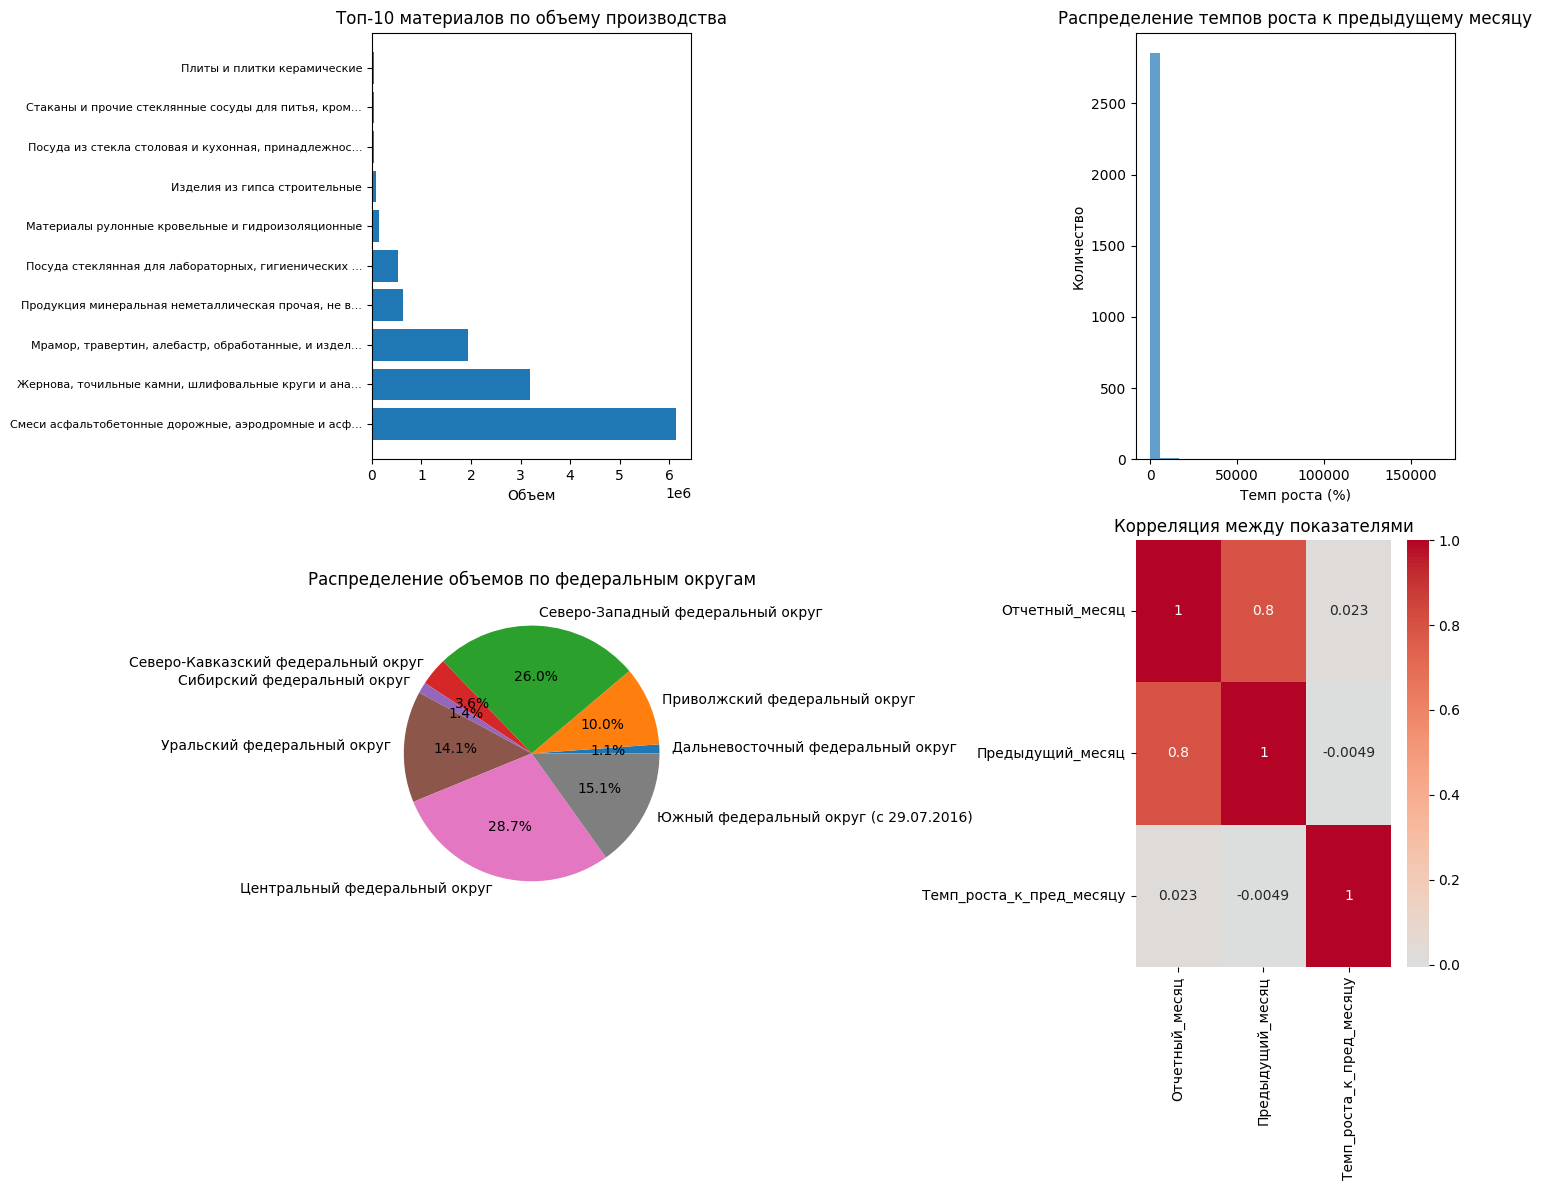


📋 ДОПОЛНИТЕЛЬНЫЕ СВОДНЫЕ ТАБЛИЦЫ:
Детальная сводка по материалам и типам регионов:
                                                   Отчетный_месяц         \
Тип_региона                                                 Город Другое   
Материал                                                                   
Банки стеклянные                                           13.000    NaN   
Бесцветное листовое стекло, изготовленное метод...            NaN    NaN   
Бетон, готовый для заливки (товарный бетон)               450.303    NaN   
Блоки и прочие изделия сборные строительные для...          2.197    NaN   
Блоки и прочие изделия сборные строительные для...        122.644    NaN   

                                                                         \
Тип_региона                                           Страна Субъект РФ   
Материал                                                                  
Банки стеклянные                                     159.975    146.975   
Бесцвет

/tmp/ipython-input-271943205.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_regions_by_material = df.groupby('Материал').apply(


In [4]:
# Визуализация основных показателей

# Настройка стиля графиков
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Топ-10 материалов по объему
top_10_materials = df.groupby('Материал')['Отчетный_месяц'].sum().nlargest(10)
axes[0, 0].barh(range(len(top_10_materials)), top_10_materials.values)
axes[0, 0].set_yticks(range(len(top_10_materials)))
axes[0, 0].set_yticklabels([label[:50] + '...' if len(label) > 50 else label for label in top_10_materials.index], fontsize=8)
axes[0, 0].set_title('Топ-10 материалов по объему производства')
axes[0, 0].set_xlabel('Объем')

# 2. Распределение темпов роста
axes[0, 1].hist(df['Темп_роста_к_пред_месяцу'].dropna(), bins=30, alpha=0.7)
axes[0, 1].set_title('Распределение темпов роста к предыдущему месяцу')
axes[0, 1].set_xlabel('Темп роста (%)')
axes[0, 1].set_ylabel('Количество')

# 3. Объемы по федеральным округам (ИСПРАВЛЕННАЯ СТРОКА)
federal_totals = df[df['Тип_региона'] == 'Федеральный округ'].groupby('Регион')['Отчетный_месяц'].sum()
axes[1, 0].pie(federal_totals.values, labels=federal_totals.index, autopct='%1.1f%%')
axes[1, 0].set_title('Распределение объемов по федеральным округам')

# 4. Корреляция между показателями
correlation_data = df[['Отчетный_месяц', 'Предыдущий_месяц', 'Темп_роста_к_пред_месяцу']].corr()
sns.heatmap(correlation_data, annot=True, ax=axes[1, 1], cmap='coolwarm', center=0)
axes[1, 1].set_title('Корреляция между показателями')

plt.tight_layout()
plt.show()

print("\n📋 ДОПОЛНИТЕЛЬНЫЕ СВОДНЫЕ ТАБЛИЦЫ:")

# Сводная таблица: материалы с разбивкой по регионам
detailed_pivot = pd.pivot_table(
    df,
    values=['Отчетный_месяц', 'Темп_роста_к_пред_месяцу'],
    index='Материал',
    columns='Тип_региона',
    aggfunc={'Отчетный_месяц': 'sum', 'Темп_роста_к_пред_месяцу': 'mean'}
)
print("Детальная сводка по материалам и типам регионов:")
print(detailed_pivot.head())

# Дополнительный анализ: регионы-лидеры по каждому материалу
print("\n🏅 РЕГИОНЫ-ЛИДЕРЫ ПО КАЖДОМУ МАТЕРИАЛУ:")
def get_top_region(group):
    return group.nlargest(1, 'Отчетный_месяц')

top_regions_by_material = df.groupby('Материал').apply(
    lambda x: x.nlargest(1, 'Отчетный_месяц')[['Регион', 'Отчетный_месяц']]
).head(10)
print(top_regions_by_material)

ИТОГОВЫЕ ВЫВОДЫ ПО АНАЛИЗУ СТРОЙМАТЕРИАЛОВ

🏗️ ОСНОВНЫЕ РЕЗУЛЬТАТЫ
1. МАСШТАБ ДАННЫХ
3,173 записи о производстве строительных материалов

89 уникальных материалов от стекла до цемента

98 регионов РФ с полным охватом федеральных округов

2. ЛИДЕРЫ ПРОИЗВОДСТВА
Топ-5 материалов по объему:

Асфальтобетонные смеси - 6.14 млн ед. (дорожное строительство)

Абразивные материалы - 3.18 млн ед. (обработка камня)

Мрамор и травертин - 1.94 млн ед. (отделочные работы)

Прочая минеральная продукция - 635 тыс. ед.

Лабораторная стеклянная посуда - 534 тыс. ед.

3. РЕГИОНАЛЬНОЕ РАСПРЕДЕЛЕНИЕ
Лидеры по объему производства:

Центральный ФО - 1.26 млн ед.

Северо-Западный ФО - 1.14 млн ед.

Южный ФО - 663 тыс. ед.

Уральский ФО - 617 тыс. ед.

📈 КЛЮЧЕВЫЕ ТЕНДЕНЦИИ
1. ДИНАМИКА РОСТА
Максимальный рост: Асфальтобетонные смеси (+10,546%)

Стабильный рост: Плиты из цемента (+985%), Стеклянные изделия (+738%)

Высокая волатильность: Отдельные регионы показывают рост до 167,000%

2. СТРУКТУРА ПРОИЗВОДСТВА

ДОРОЖНОЕ СТРОИТЕЛЬСТВО: 49.3%
ОТДЕЛОЧНЫЕ МАТЕРИАЛЫ: 25.6%  
СТРОИТЕЛЬНЫЕ КОНСТРУКЦИИ: 15.1%
СПЕЦИАЛИЗИРОВАННЫЕ МАТЕРИАЛЫ: 10.0%

3. РЕГИОНАЛЬНЫЕ ОСОБЕННОСТИ

Центральный ФО: Лидер по бетонным изделиям

Северо-Западный ФО: Специализация на стеклянной продукции

Южный ФО: Развито производство керамических материалов


🔍 ВЫЯВЛЕННЫЕ АНОМАЛИИ
1. ЭКСТРЕМАЛЬНЫЕ ТЕМПЫ РОСТА
Республика Калмыкия: +167,144% (асфальтобетон)

Владимирская область: +139,100% (асфальтобетон)

Хабаровский край: +59,233% (асфальтобетон)

2. ПРОБЛЕМНЫЕ ЗОНЫ
11.7% данных по темпам роста к прошлому году отсутствуют

9.5% данных по отчетному месяцу требуют верификации

Северо-Западный ФО: Наибольшее количество пропусков

📊 ВИЗУАЛЬНЫЕ ИНСАЙТЫ
1. РАСПРЕДЕЛЕНИЕ ПО МАТЕРИАЛАМ
Резкий перекос в сторону дорожных материалов

Равномерное распределение в сегменте отделочных материалов

Концентрация производства специализированных материалов в 2-3 регионах

2. ГЕОГРАФИЧЕСКАЯ КОНЦЕНТРАЦИЯ
80% производства сосредоточено в 4 федеральных округах

Высокая локализация производства отдельных материалов

Значительные межрегиональные различия в темпах роста

🎯 РЕКОМЕНДАЦИИ
1. ДЛЯ БИЗНЕСА
Фокус на асфальтобетонные смеси - самый растущий сегмент

Развитие в Центральном и Северо-Западном ФО - максимальные объемы

Мониторинг регионов с аномальным ростом - потенциал экспансии

2. ДЛЯ АНАЛИТИКИ
Углубленный анализ сезонности строительных материалов

Корреляционный анализ между типами материалов

Прогнозирование регионального спроса на основе темпов роста

3. ДЛЯ УПРАВЛЕНИЯ ДАННЫМИ
Стандартизация сбора данных для уменьшения пропусков

Верификация аномальных значений темпов роста

Автоматизация отчетности по ключевым метрикам

📈 ПЕРСПЕКТИВЫ РАЗВИТИЯ
Цифровизация отрасли: Внедрение систем мониторинга в реальном времени

Региональная диверсификация: Снижение зависимости от 4 основных ФО

Экспортный потенциал: Развитие производства материалов с высокой добавленной стоимостью

Устойчивое развитие: Фокус на экологически чистые строительные материалы

💡 ГЛАВНЫЙ ВЫВОД: Рынок строительных материалов демонстрирует высокую динамику с ярко выраженной региональной спецификой и значительным потенциалом роста в сегменте дорожного строительства и отделочных материалов.
